
# Machine Learning Lab — Linear Regression
## Least Squares, Assumptions, Optimization, Inference, Diagnostics, and Practical Extensions

**Dataset:** Kaggle Advertising Sales Dataset  
**Predictors:** TV, Radio, Newspaper advertising budgets  
**Target:** Sales

### Kaggle dataset
`https://www.kaggle.com/datasets/yasserh/advertising-sales-dataset`

---

## Learning Outcomes

By the end of this lab, students should be able to:

1. Place Linear Regression inside the statistical-learning model $Y=f(X)+\varepsilon$.
2. Explain fitted values, residuals, RSS, and least squares geometrically and algebraically.
3. Diagnose the major Linear Regression failure modes and apply a defensible remedy.
4. Derive **Multiple Linear Regression in matrix form** from the least-squares objective.
5. Implement Linear Regression from scratch using only matrix operations:
   - **Closed Form / Normal Equation**
   - **First-order optimization: Gradient Descent**
   - **Second-order optimization: Newton/Hessian method**
6. Visualize why least-squares optimization is a **convex problem**.
7. Calculate **MSE, RMSE, RSE, and $R^2$** and understand the **overall F-test**.
8. Interpret coefficients, standard errors, confidence intervals, and t-tests without confusing association with causation.
9. Explain the multiple-regression phrase **"holding the other predictors fixed."**
10. Explore interactions and polynomial terms while recognizing that these models can still be linear in their coefficients.
11. Compare the hand-derived solution with `scikit-learn` and contrast Linear Regression with a simple KNN regression baseline.



# 1. Problem Statement

A company advertises its product using three media channels:

- **TV**
- **Radio**
- **Newspaper**

The company wants to answer:

> **Can we predict product sales from advertising expenditure?**

A multiple Linear Regression model can be written as:
$$
[
\hat{y}
=
\beta_0
+
\beta_1 x_{TV}
+
\beta_2 x_{Radio}
+
\beta_3 x_{Newspaper}
]
$$
where:

- $\hat{y}$ = predicted sales
- $\beta_0$ = intercept
- $\beta_1,\beta_2,\beta_3$ = coefficients
- $x$ values = advertising budgets

The model will learn the coefficients from historical data.

## 1.1 Where Linear Regression Fits in Statistical Learning

A common supervised-learning viewpoint is
$$
[
Y=f(X)+\varepsilon
]
$$
where:

- $f(X)$ is the systematic relationship we want to learn,
- $\varepsilon$ represents irreducible noise.

Linear Regression makes the deliberately simple choice
$$
[
f(X)=\beta_0+\beta_1X_1+\cdots+\beta_pX_p.
]
$$
Why begin here?

- It is fast and interpretable.
- Its loss and optimum can be derived exactly.
- Uncertainty in the coefficients can be quantified.
- Its failure modes are easy to visualize.
- Many later models can be understood as modifications of this baseline.



# 2. Import Libraries and Define a Consistent Color Palette

Different colors are deliberately used for different concepts throughout the notebook.

This makes it easier to distinguish:

- original observations,
- regression lines,
- violations,
- corrected models,
- residuals,
- optimization methods.

In [5]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

# statsmodels: formal regression diagnostics and GLS
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

# sklearn: library implementation and selected remedies
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, PowerTransformer
from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline

np.random.seed(42)

# ----------------------------------------------------------
# Color palette
# ----------------------------------------------------------
COLORS = {
    "data": "#1f77b4",          # blue
    "fit": "#ff7f0e",           # orange
    "residual": "#d62728",      # purple
    "problem": "#d62728",       # red
    "solution": "#2ca02c",      # green
    "secondary": "#17becf",     # cyan
    "accent": "#e377c2",        # pink
    "dark": "#2f2f2f",          # dark gray
    "gold": "#bcbd22"           # olive/gold
}

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Libraries imported successfully.")

Libraries imported successfully.


# 3. Load the Kaggle Advertising Dataset

We use the **Advertising Sales** dataset available on Kaggle.

### Recommended classroom workflow

1. Open the Kaggle link shown at the top of the notebook.
2. Download the CSV.
3. Place it in the same folder as this notebook.
4. Run the notebook.

### Why does this notebook also contain a fallback copy?

A lab notebook should still run when internet access or Kaggle authentication is unavailable. Therefore the loader tries, in order:

1. A locally downloaded Kaggle CSV.
2. `kagglehub` if available.
3. An **embedded snapshot of the same 200-row Advertising dataset** as an offline fallback.

This keeps the lab reproducible while still teaching with the Kaggle dataset.

In [6]:
# ----------------------------------------------------------
# Robust Kaggle dataset loader with OFFLINE fallback
# ----------------------------------------------------------
from io import StringIO

EMBEDDED_ADVERTISING_CSV = r""",TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
6,8.7,48.9,75,7.2
7,57.5,32.8,23.5,11.8
8,120.2,19.6,11.6,13.2
9,8.6,2.1,1,4.8
10,199.8,2.6,21.2,10.6
11,66.1,5.8,24.2,8.6
12,214.7,24,4,17.4
13,23.8,35.1,65.9,9.2
14,97.5,7.6,7.2,9.7
15,204.1,32.9,46,19
16,195.4,47.7,52.9,22.4
17,67.8,36.6,114,12.5
18,281.4,39.6,55.8,24.4
19,69.2,20.5,18.3,11.3
20,147.3,23.9,19.1,14.6
21,218.4,27.7,53.4,18
22,237.4,5.1,23.5,12.5
23,13.2,15.9,49.6,5.6
24,228.3,16.9,26.2,15.5
25,62.3,12.6,18.3,9.7
26,262.9,3.5,19.5,12
27,142.9,29.3,12.6,15
28,240.1,16.7,22.9,15.9
29,248.8,27.1,22.9,18.9
30,70.6,16,40.8,10.5
31,292.9,28.3,43.2,21.4
32,112.9,17.4,38.6,11.9
33,97.2,1.5,30,9.6
34,265.6,20,0.3,17.4
35,95.7,1.4,7.4,9.5
36,290.7,4.1,8.5,12.8
37,266.9,43.8,5,25.4
38,74.7,49.4,45.7,14.7
39,43.1,26.7,35.1,10.1
40,228,37.7,32,21.5
41,202.5,22.3,31.6,16.6
42,177,33.4,38.7,17.1
43,293.6,27.7,1.8,20.7
44,206.9,8.4,26.4,12.9
45,25.1,25.7,43.3,8.5
46,175.1,22.5,31.5,14.9
47,89.7,9.9,35.7,10.6
48,239.9,41.5,18.5,23.2
49,227.2,15.8,49.9,14.8
50,66.9,11.7,36.8,9.7
51,199.8,3.1,34.6,11.4
52,100.4,9.6,3.6,10.7
53,216.4,41.7,39.6,22.6
54,182.6,46.2,58.7,21.2
55,262.7,28.8,15.9,20.2
56,198.9,49.4,60,23.7
57,7.3,28.1,41.4,5.5
58,136.2,19.2,16.6,13.2
59,210.8,49.6,37.7,23.8
60,210.7,29.5,9.3,18.4
61,53.5,2,21.4,8.1
62,261.3,42.7,54.7,24.2
63,239.3,15.5,27.3,15.7
64,102.7,29.6,8.4,14
65,131.1,42.8,28.9,18
66,69,9.3,0.9,9.3
67,31.5,24.6,2.2,9.5
68,139.3,14.5,10.2,13.4
69,237.4,27.5,11,18.9
70,216.8,43.9,27.2,22.3
71,199.1,30.6,38.7,18.3
72,109.8,14.3,31.7,12.4
73,26.8,33,19.3,8.8
74,129.4,5.7,31.3,11
75,213.4,24.6,13.1,17
76,16.9,43.7,89.4,8.7
77,27.5,1.6,20.7,6.9
78,120.5,28.5,14.2,14.2
79,5.4,29.9,9.4,5.3
80,116,7.7,23.1,11
81,76.4,26.7,22.3,11.8
82,239.8,4.1,36.9,12.3
83,75.3,20.3,32.5,11.3
84,68.4,44.5,35.6,13.6
85,213.5,43,33.8,21.7
86,193.2,18.4,65.7,15.2
87,76.3,27.5,16,12
88,110.7,40.6,63.2,16
89,88.3,25.5,73.4,12.9
90,109.8,47.8,51.4,16.7
91,134.3,4.9,9.3,11.2
92,28.6,1.5,33,7.3
93,217.7,33.5,59,19.4
94,250.9,36.5,72.3,22.2
95,107.4,14,10.9,11.5
96,163.3,31.6,52.9,16.9
97,197.6,3.5,5.9,11.7
98,184.9,21,22,15.5
99,289.7,42.3,51.2,25.4
100,135.2,41.7,45.9,17.2
101,222.4,4.3,49.8,11.7
102,296.4,36.3,100.9,23.8
103,280.2,10.1,21.4,14.8
104,187.9,17.2,17.9,14.7
105,238.2,34.3,5.3,20.7
106,137.9,46.4,59,19.2
107,25,11,29.7,7.2
108,90.4,0.3,23.2,8.7
109,13.1,0.4,25.6,5.3
110,255.4,26.9,5.5,19.8
111,225.8,8.2,56.5,13.4
112,241.7,38,23.2,21.8
113,175.7,15.4,2.4,14.1
114,209.6,20.6,10.7,15.9
115,78.2,46.8,34.5,14.6
116,75.1,35,52.7,12.6
117,139.2,14.3,25.6,12.2
118,76.4,0.8,14.8,9.4
119,125.7,36.9,79.2,15.9
120,19.4,16,22.3,6.6
121,141.3,26.8,46.2,15.5
122,18.8,21.7,50.4,7
123,224,2.4,15.6,11.6
124,123.1,34.6,12.4,15.2
125,229.5,32.3,74.2,19.7
126,87.2,11.8,25.9,10.6
127,7.8,38.9,50.6,6.6
128,80.2,0,9.2,8.8
129,220.3,49,3.2,24.7
130,59.6,12,43.1,9.7
131,0.7,39.6,8.7,1.6
132,265.2,2.9,43,12.7
133,8.4,27.2,2.1,5.7
134,219.8,33.5,45.1,19.6
135,36.9,38.6,65.6,10.8
136,48.3,47,8.5,11.6
137,25.6,39,9.3,9.5
138,273.7,28.9,59.7,20.8
139,43,25.9,20.5,9.6
140,184.9,43.9,1.7,20.7
141,73.4,17,12.9,10.9
142,193.7,35.4,75.6,19.2
143,220.5,33.2,37.9,20.1
144,104.6,5.7,34.4,10.4
145,96.2,14.8,38.9,11.4
146,140.3,1.9,9,10.3
147,240.1,7.3,8.7,13.2
148,243.2,49,44.3,25.4
149,38,40.3,11.9,10.9
150,44.7,25.8,20.6,10.1
151,280.7,13.9,37,16.1
152,121,8.4,48.7,11.6
153,197.6,23.3,14.2,16.6
154,171.3,39.7,37.7,19
155,187.8,21.1,9.5,15.6
156,4.1,11.6,5.7,3.2
157,93.9,43.5,50.5,15.3
158,149.8,1.3,24.3,10.1
159,11.7,36.9,45.2,7.3
160,131.7,18.4,34.6,12.9
161,172.5,18.1,30.7,14.4
162,85.7,35.8,49.3,13.3
163,188.4,18.1,25.6,14.9
164,163.5,36.8,7.4,18
165,117.2,14.7,5.4,11.9
166,234.5,3.4,84.8,11.9
167,17.9,37.6,21.6,8
168,206.8,5.2,19.4,12.2
169,215.4,23.6,57.6,17.1
170,284.3,10.6,6.4,15
171,50,11.6,18.4,8.4
172,164.5,20.9,47.4,14.5
173,19.6,20.1,17,7.6
174,168.4,7.1,12.8,11.7
175,222.4,3.4,13.1,11.5
176,276.9,48.9,41.8,27
177,248.4,30.2,20.3,20.2
178,170.2,7.8,35.2,11.7
179,276.7,2.3,23.7,11.8
180,165.6,10,17.6,12.6
181,156.6,2.6,8.3,10.5
182,218.5,5.4,27.4,12.2
183,56.2,5.7,29.7,8.7
184,287.6,43,71.8,26.2
185,253.8,21.3,30,17.6
186,205,45.1,19.6,22.6
187,139.5,2.1,26.6,10.3
188,191.1,28.7,18.2,17.3
189,286,13.9,3.7,15.9
190,18.7,12.1,23.4,6.7
191,39.5,41.1,5.8,10.8
192,75.5,10.8,6,9.9
193,17.2,4.1,31.6,5.9
194,166.8,42,3.6,19.6
195,149.7,35.6,6,17.3
196,38.2,3.7,13.8,7.6
197,94.2,4.9,8.1,9.7
198,177,9.3,6.4,12.8
199,283.6,42,66.2,25.5
200,232.1,8.6,8.7,13.4"""


def load_advertising_data():
    # 1) Look for a manually downloaded local CSV.
    possible_names = [
        "Advertising Budget and Sales.csv",
        "Advertising.csv",
        "advertising.csv",
        "Advertising Sales.csv"
    ]

    for name in possible_names:
        path = Path(name)
        if path.exists():
            print(f"Loaded local Kaggle/Advertising file: {path}")
            return pd.read_csv(path), f"Local file: {path}"

    # 2) Try KaggleHub for students who have it installed/configured.
    try:
        import kagglehub

        dataset_dir = Path(
            kagglehub.dataset_download("yasserh/advertising-sales-dataset")
        )
        csv_files = list(dataset_dir.rglob("*.csv"))

        if len(csv_files) == 0:
            raise FileNotFoundError("No CSV found inside Kaggle dataset folder.")

        print(f"Loaded through KaggleHub: {csv_files[0]}")
        return pd.read_csv(csv_files[0]), "KaggleHub: yasserh/advertising-sales-dataset"

    except Exception as e:
        print("Local Kaggle file / KaggleHub unavailable.")
        print("Using the embedded offline Advertising dataset snapshot.")
        print("Reason:", type(e).__name__)

    # 3) Offline fallback: same standard Advertising data.
    return pd.read_csv(StringIO(EMBEDDED_ADVERTISING_CSV)), "Embedded offline snapshot"


df_raw, data_source = load_advertising_data()

print("\nSource used:", data_source)
print("Raw shape:", df_raw.shape)
df_raw.head()

100%|██████████| 2.25k/2.25k [00:00<00:00, 2.25MB/s]

Extracting files...
Loaded through KaggleHub: /root/.cache/kagglehub/datasets/yasserh/advertising-sales-dataset/versions/1/Advertising Budget and Sales.csv

Source used: KaggleHub: yasserh/advertising-sales-dataset
Raw shape: (200, 5)


,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1000,37.8000,69.2000,22.1000
1,2,44.5000,39.3000,45.1000,10.4000
2,3,17.2000,45.9000,69.3000,9.3000
3,4,151.5000,41.3000,58.5000,18.5000
4,5,180.8000,10.8000,58.4000,12.9000


## 3.1 Clean Column Names

Different copies of the dataset sometimes use slightly different capitalization.

We standardize the names so the remaining code is consistent.

In [7]:
df = df_raw.copy()

# Remove unnamed/index-like columns
df = df.loc[:, ~df.columns.astype(str).str.contains("^Unnamed", case=False, regex=True)]

# Normalize column names
df.columns = [
    str(c).strip().lower().replace(" ", "_")
    for c in df.columns
]

# Handle common alternative names
rename_map = {
    "tv_ad_budget_($)": "tv",
    "radio_ad_budget_($)": "radio",
    "newspaper_ad_budget_($)": "newspaper",
    "sales_($)": "sales",
    "sales": "sales",
    "tv": "tv",
    "radio": "radio",
    "newspaper": "newspaper"
}

df = df.rename(columns={c: rename_map.get(c, c) for c in df.columns})

# If a numeric index column remains, drop it
for candidate in ["index", "id", "unnamed:_0"]:
    if candidate in df.columns:
        df = df.drop(columns=candidate)

required = ["tv", "radio", "newspaper", "sales"]

missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(
        f"Required columns missing: {missing}\nAvailable columns: {df.columns.tolist()}"
    )

df = df[required].copy()

print("Clean shape:", df.shape)
df.head()

Clean shape: (200, 4)


,tv,radio,newspaper,sales
0,230.1000,37.8000,69.2000,22.1000
1,44.5000,39.3000,45.1000,10.4000
2,17.2000,45.9000,69.3000,9.3000
3,151.5000,41.3000,58.5000,18.5000
4,180.8000,10.8000,58.4000,12.9000


In [8]:
print("Missing values:")
display(df.isna().sum().to_frame("Missing"))

print("\nDuplicate rows:", df.duplicated().sum())

display(df.describe())

Missing values:


,Missing
tv,0
radio,0
newspaper,0
sales,0



Duplicate rows: 0


,tv,radio,newspaper,sales
count,200.0000,200.0000,200.0000,200.0000
mean,147.0425,23.2640,30.5540,14.0225
std,85.8542,14.8468,21.7786,5.2175
min,0.7000,0.0000,0.3000,1.6000
25%,74.3750,9.9750,12.7500,10.3750
50%,149.7500,22.9000,25.7500,12.9000
75%,218.8250,36.5250,45.1000,17.4000
max,296.4000,49.6000,114.0000,27.0000


# 4. Initial Exploratory Visualization

Before fitting any model, inspect the data.

Questions to ask:

1. Does sales appear to increase when advertising increases?
2. Which advertising medium has the strongest visible relationship?
3. Is the relationship roughly linear?
4. Are there unusual observations?

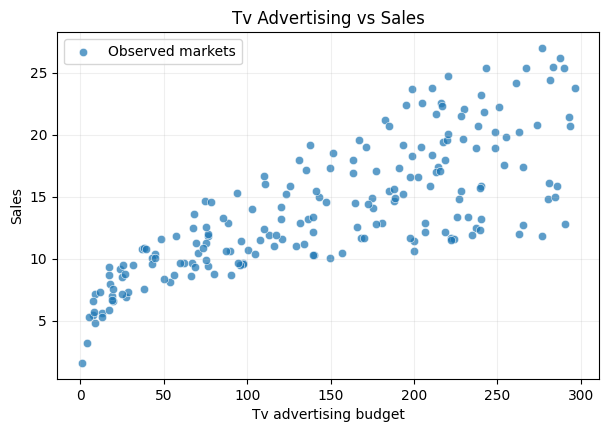

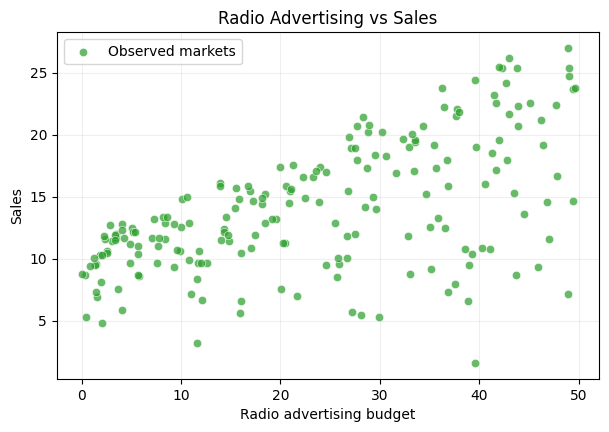

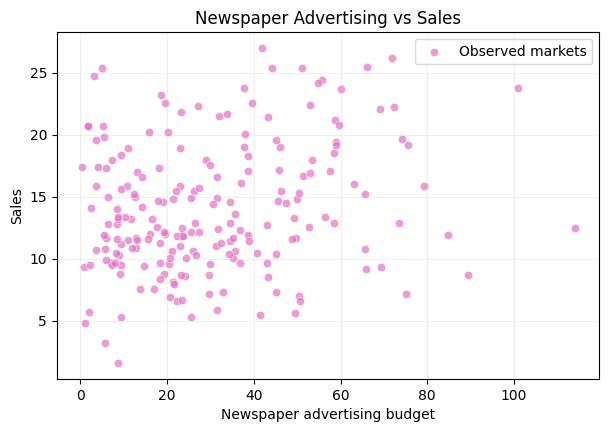

In [9]:
feature_colors = {
    "tv": COLORS["data"],
    "radio": COLORS["solution"],
    "newspaper": COLORS["accent"]
}

for feature in ["tv", "radio", "newspaper"]:
    plt.figure(figsize=(7, 4.5))
    plt.scatter(
        df[feature],
        df["sales"],
        color=feature_colors[feature],
        alpha=0.72,
        edgecolor="white",
        linewidth=0.5,
        label="Observed markets"
    )
    plt.xlabel(f"{feature.title()} advertising budget")
    plt.ylabel("Sales")
    plt.title(f"{feature.title()} Advertising vs Sales")
    plt.legend()
    plt.grid(alpha=0.20)
    plt.show()

# 5. A Simple Regression Visualization

To introduce the regression line visually, we first use only **TV advertising**.
$$
[
\hat{Sales} = \beta_0 + \beta_1(TV)
]
$$
Later, the final model will use all three predictors.

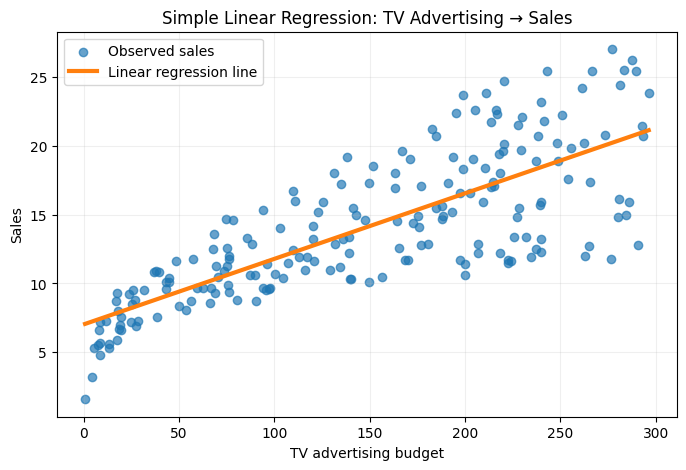

Intercept: 7.0326
TV coefficient: 0.0475


In [10]:
X_tv = df[["tv"]].to_numpy()
y_all = df["sales"].to_numpy()

simple_model = LinearRegression()
simple_model.fit(X_tv, y_all)
simple_pred = simple_model.predict(X_tv)

order = np.argsort(df["tv"].to_numpy())

plt.figure(figsize=(8, 5))
plt.scatter(
    df["tv"],
    y_all,
    color=COLORS["data"],
    alpha=0.68,
    label="Observed sales"
)
plt.plot(
    df["tv"].to_numpy()[order],
    simple_pred[order],
    color=COLORS["fit"],
    linewidth=3,
    label="Linear regression line"
)
plt.xlabel("TV advertising budget")
plt.ylabel("Sales")
plt.title("Simple Linear Regression: TV Advertising → Sales")
plt.legend()
plt.grid(alpha=0.20)
plt.show()

print(f"Intercept: {simple_model.intercept_:.4f}")
print(f"TV coefficient: {simple_model.coef_[0]:.4f}")

## 5.1 Fitted Values, Residuals, and the Least-Squares Idea

For observation $i$:
$$
[
\hat y_i=\hat\beta_0+\hat\beta_1x_i
]
$$

and its residual is
$$
[
e_i=y_i-\hat y_i.
]
$$
Least squares chooses the coefficients that minimize
$$
[
RSS=\sum_{i=1}^{N}e_i^2.
]
$$
The vertical segments below are the residuals. Squaring them means large errors are penalized more strongly.

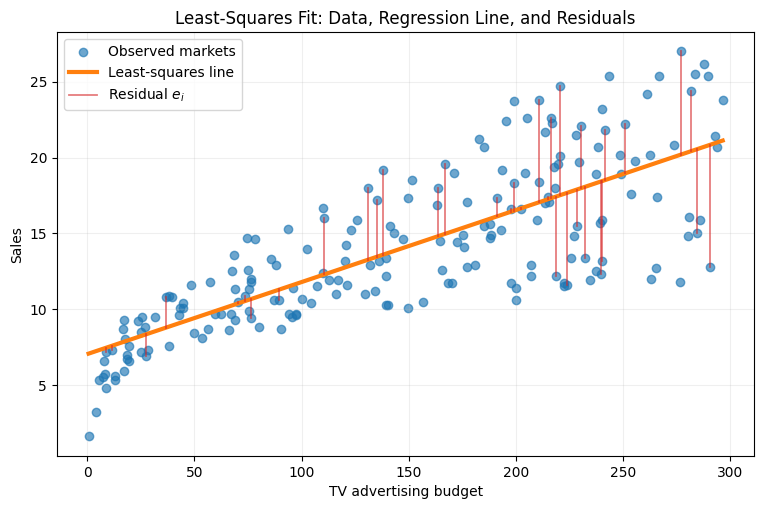

In [11]:
# Visualize residuals for the TV-only regression.
plt.figure(figsize=(9, 5.5))

plt.scatter(
    df["tv"], y_all,
    color=COLORS["data"],
    alpha=0.65,
    label="Observed markets"
)

plt.plot(
    df["tv"].to_numpy()[order],
    simple_pred[order],
    color=COLORS["fit"],
    linewidth=3,
    label="Least-squares line"
)

# Draw only a subset of residuals so the figure remains readable.
residual_demo_idx = np.linspace(0, len(df)-1, 35, dtype=int)
for j, i in enumerate(residual_demo_idx):
    plt.plot(
        [df["tv"].iloc[i], df["tv"].iloc[i]],
        [y_all[i], simple_pred[i]],
        color=COLORS["residual"],
        alpha=0.60,
        linewidth=1.3,
        label="Residual $e_i$" if j == 0 else None
    )

plt.xlabel("TV advertising budget")
plt.ylabel("Sales")
plt.title("Least-Squares Fit: Data, Regression Line, and Residuals")
plt.legend()
plt.grid(alpha=0.20)
plt.show()

## 5.2 Geometric View: Least Squares as Projection

In matrix form,
$$
[
\mathbf y=X\beta+\varepsilon.
]
$$
The fitted vector $\hat{\mathbf y}$ lies in the column space of $X$. Least squares chooses the point in that space closest to $\mathbf y$.

At the optimum, the residual vector is orthogonal to the columns of the design matrix:
$$
[
X^T(\mathbf y-X\hat\beta)=0.
]
$$
This single condition gives the **normal equations** later in the notebook.

# PART A — ASSUMPTIONS, FAILURE MODES, AND DIAGNOSTICS

A coefficient table is not enough. Before trusting a Linear Regression model, inspect how and why it can fail.

## Six classic failure modes

1. **Non-linearity**
2. **Correlated errors**
3. **Non-constant variance (heteroscedasticity)**
4. **Outliers**
5. **High-leverage points**
6. **Collinearity**

We will also inspect **residual normality** because it matters for classical small-sample inference.

> Important distinction: not every issue is fixed by the same transformation or algorithm. Diagnose the cause first; then choose the remedy.

In [12]:
X_assump = df[["tv", "radio", "newspaper"]]
y_assump = df["sales"]

X_assump_const = sm.add_constant(X_assump)
baseline_ols = sm.OLS(y_assump, X_assump_const).fit()

baseline_fitted = baseline_ols.fittedvalues
baseline_resid = baseline_ols.resid

print(baseline_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           1.58e-96
Time:                        05:42:12   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9389      0.312      9.422      0.0

# Assumption 1 — Linearity

## Assumption

The expected target should be a linear combination of the predictors.
$$
[
E[y|X]
=
\beta_0+\beta_1x_1+\cdots+\beta_px_p
]
$$
## What does the problem look like?

If the actual relationship is curved but we fit a straight line:

- the model systematically under-predicts some regions,
- over-predicts other regions,
- residuals form a curved pattern.

## Diagnostic

Plot:

\[
Residuals \; vs \; Fitted\ Values
\]

### Desired pattern
A random cloud around zero.

### Problem pattern
A curve, U-shape, wave, or another systematic structure.

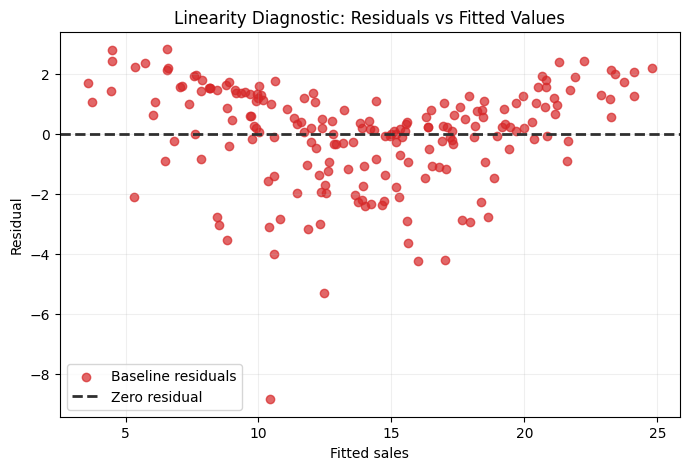

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(
    baseline_fitted,
    baseline_resid,
    color=COLORS["residual"],
    alpha=0.70,
    label="Baseline residuals"
)
plt.axhline(
    0,
    color=COLORS["dark"],
    linestyle="--",
    linewidth=2,
    label="Zero residual"
)
plt.xlabel("Fitted sales")
plt.ylabel("Residual")
plt.title("Linearity Diagnostic: Residuals vs Fitted Values")
plt.legend()
plt.grid(alpha=0.20)
plt.show()

## Controlled Linearity Violation

The original dataset may not show a dramatic violation.

For teaching purposes, we create a **problem copy of the same Kaggle data** by adding a quadratic TV effect:
$$
[
Sales_{problem}
=
Sales + c(TV-\overline{TV})^2
]
$$
We then deliberately fit an inadequate straight-line model.

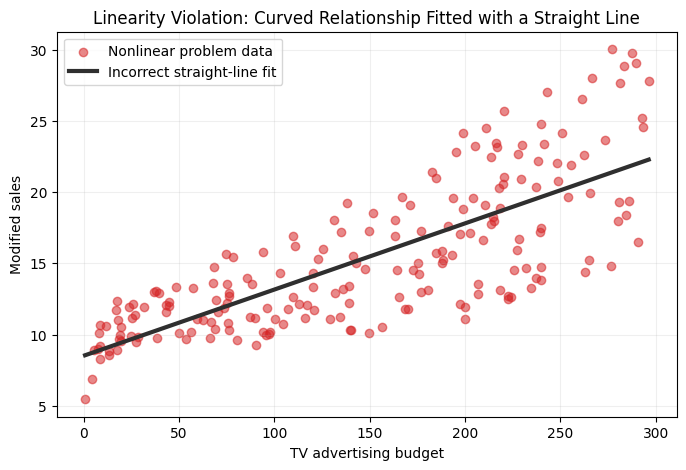

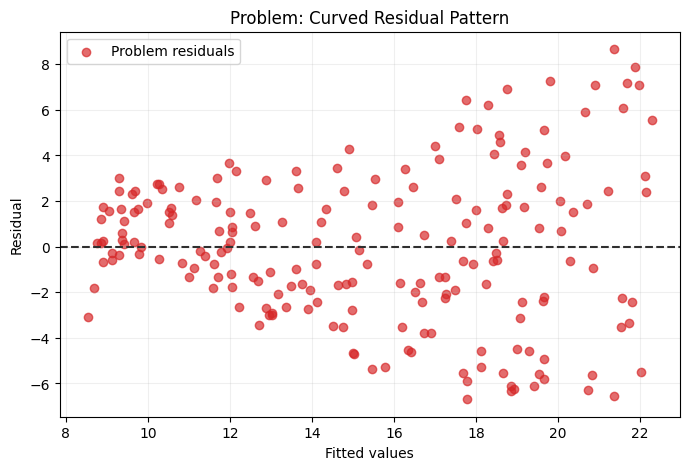

In [14]:
rng = np.random.default_rng(42)

tv = df["tv"].to_numpy()
tv_centered = tv - tv.mean()

# Controlled nonlinear version of the target
y_nonlinear = (
    df["sales"].to_numpy()
    + 0.00018 * (tv_centered ** 2)
)

# Wrong model: only straight-line TV term
X_linear_bad = sm.add_constant(tv)
model_linear_bad = sm.OLS(y_nonlinear, X_linear_bad).fit()

pred_linear_bad = model_linear_bad.predict(X_linear_bad)
res_linear_bad = y_nonlinear - pred_linear_bad

plt.figure(figsize=(8, 5))
plt.scatter(
    tv,
    y_nonlinear,
    color=COLORS["problem"],
    alpha=0.55,
    label="Nonlinear problem data"
)
order = np.argsort(tv)
plt.plot(
    tv[order],
    pred_linear_bad[order],
    color=COLORS["dark"],
    linewidth=3,
    label="Incorrect straight-line fit"
)
plt.xlabel("TV advertising budget")
plt.ylabel("Modified sales")
plt.title("Linearity Violation: Curved Relationship Fitted with a Straight Line")
plt.legend()
plt.grid(alpha=0.20)
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(
    pred_linear_bad,
    res_linear_bad,
    color=COLORS["problem"],
    alpha=0.68,
    label="Problem residuals"
)
plt.axhline(0, color=COLORS["dark"], linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residual")
plt.title("Problem: Curved Residual Pattern")
plt.legend()
plt.grid(alpha=0.20)
plt.show()

## Solution to Nonlinearity

Possible remedies include:

1. Add a meaningful nonlinear feature such as $TV^2$.
2. Transform a predictor.
3. Use Polynomial Regression.
4. Use a different nonlinear model if the relationship is fundamentally nonlinear.

For this example:
$$
[
Sales
=
\beta_0+\beta_1TV+\beta_2TV^2
]
$$
Although this is called **Polynomial Regression**, it is still linear in its coefficients.

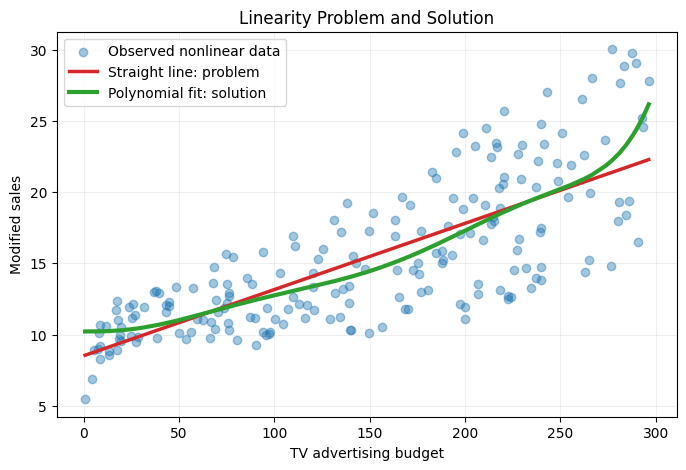

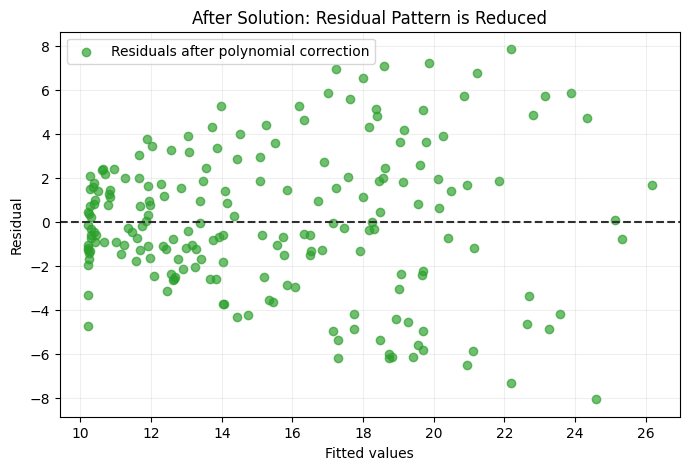

MSE with incorrect straight line : 10.8334
MSE after polynomial correction : 10.2941


In [15]:
# Polynomial solution: TV and TV^2
poly = PolynomialFeatures(degree=7, include_bias=False)
X_poly = poly.fit_transform(tv.reshape(-1, 1))

poly_model = LinearRegression()
poly_model.fit(X_poly, y_nonlinear)
pred_poly = poly_model.predict(X_poly)
res_poly = y_nonlinear - pred_poly

mse_bad_linearity = mean_squared_error(y_nonlinear, pred_linear_bad)
mse_fixed_linearity = mean_squared_error(y_nonlinear, pred_poly)

plt.figure(figsize=(8, 5))
plt.scatter(
    tv,
    y_nonlinear,
    color=COLORS["data"],
    alpha=0.42,
    label="Observed nonlinear data"
)
plt.plot(
    tv[order],
    pred_linear_bad[order],
    color=COLORS["problem"],
    linewidth=2.5,
    label="Straight line: problem"
)
plt.plot(
    tv[order],
    pred_poly[order],
    color=COLORS["solution"],
    linewidth=3,
    label="Polynomial fit: solution"
)
plt.xlabel("TV advertising budget")
plt.ylabel("Modified sales")
plt.title("Linearity Problem and Solution")
plt.legend()
plt.grid(alpha=0.20)
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(
    pred_poly,
    res_poly,
    color=COLORS["solution"],
    alpha=0.68,
    label="Residuals after polynomial correction"
)
plt.axhline(0, color=COLORS["dark"], linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residual")
plt.title("After Solution: Residual Pattern is Reduced")
plt.legend()
plt.grid(alpha=0.20)
plt.show()

print(f"MSE with incorrect straight line : {mse_bad_linearity:.4f}")
print(f"MSE after polynomial correction : {mse_fixed_linearity:.4f}")

# Assumption 2 — Correlated Errors

## Assumption

Residuals should not systematically depend on previous residuals.

This is especially important for:

- time-series data,
- repeated observations,
- sequential experiments,
- spatially ordered data.

<!-- ## Common problem

Autocorrelation:



1.   List item
2.   List item

$$
[
e_t = \rho e_{t-1} + \epsilon_t
]
$$
If $\rho$ is large, neighboring errors move together. -->

## Diagnostic

A common numerical diagnostic is the **Durbin–Watson statistic**.

Rough interpretation:

- around **2** → little first-order autocorrelation,
- much below 2 → positive autocorrelation,
- much above 2 → negative autocorrelation.

> For a cross-sectional advertising dataset, independence should primarily be justified by the **data collection design**. A plot alone cannot prove independence.

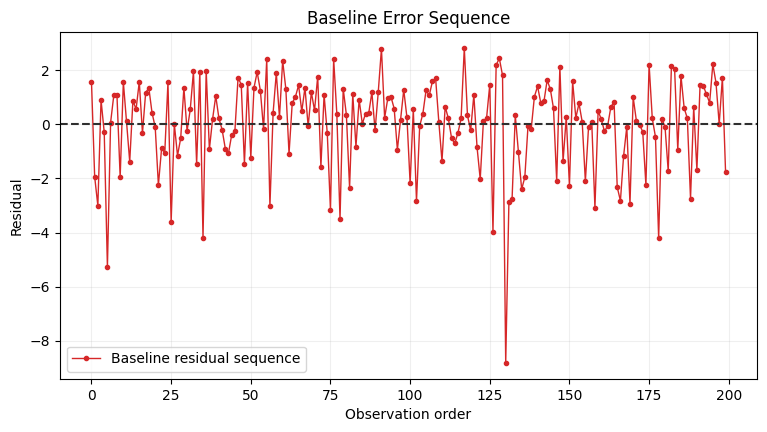

Baseline Durbin-Watson statistic: 2.0836


In [16]:
dw_baseline = durbin_watson(baseline_resid)

plt.figure(figsize=(9, 4.5))
plt.plot(
    np.arange(len(baseline_resid)),
    baseline_resid,
    color=COLORS["residual"],
    marker="o",
    markersize=3,
    linewidth=1,
    label="Baseline residual sequence"
)
plt.axhline(0, color=COLORS["dark"], linestyle="--")
plt.xlabel("Observation order")
plt.ylabel("Residual")
plt.title("Baseline Error Sequence")
plt.legend()
plt.grid(alpha=0.20)
plt.show()

print(f"Baseline Durbin-Watson statistic: {dw_baseline:.4f}")

## Controlled Independence Violation

To make the problem visible, we create an AR(1)-style correlated error sequence and add it to the Kaggle sales target.

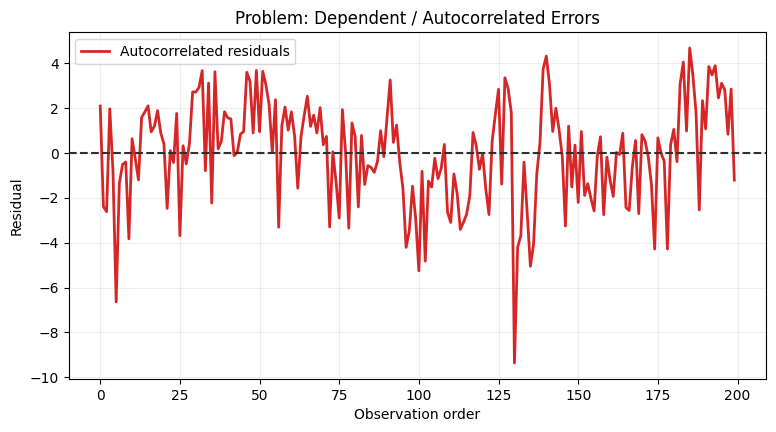

Durbin-Watson with dependent errors: 1.2249


In [17]:
rho = 0.90
innovation = rng.normal(0, 0.8, len(df))
ar_error = np.zeros(len(df))

for t in range(1, len(df)):
    ar_error[t] = rho * ar_error[t-1] + innovation[t]

y_dependent = df["sales"].to_numpy() + ar_error

X_dep = sm.add_constant(df[["tv", "radio", "newspaper"]])
ols_dep = sm.OLS(y_dependent, X_dep).fit()

dep_resid = ols_dep.resid
dw_problem = durbin_watson(dep_resid)

plt.figure(figsize=(9, 4.5))
plt.plot(
    np.arange(len(dep_resid)),
    dep_resid,
    color=COLORS["problem"],
    linewidth=2,
    label="Autocorrelated residuals"
)
plt.axhline(0, color=COLORS["dark"], linestyle="--")
plt.xlabel("Observation order")
plt.ylabel("Residual")
plt.title("Problem: Dependent / Autocorrelated Errors")
plt.legend()
plt.grid(alpha=0.20)
plt.show()

print(f"Durbin-Watson with dependent errors: {dw_problem:.4f}")

## Solution to Dependent Errors

**Do not treat random shuffling as a statistical cure.**

If dependence is real because the observations are temporal or sequential, reasonable solutions include:

- include meaningful lag variables,
- use Generalized Least Squares,
- use GLSAR for autoregressive errors,
- use a dedicated time-series regression model,
- redesign data collection if observations should have been independent.

Below we use **GLSAR** only to demonstrate how explicitly modeling AR-type error dependence can improve the residual structure.

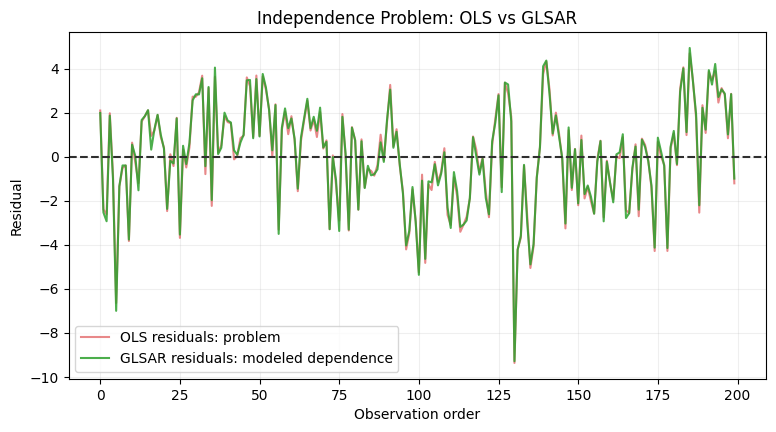

Durbin-Watson before correction: 1.2249
Durbin-Watson after GLSAR       : 1.1964


In [18]:
# GLSAR solution
glsar_model = sm.GLSAR(y_dependent, X_dep, rho=1)
glsar_result = glsar_model.iterative_fit(maxiter=20)

glsar_resid = y_dependent - glsar_result.predict(X_dep)
dw_solution = durbin_watson(glsar_resid)

plt.figure(figsize=(9, 4.5))
plt.plot(
    np.arange(len(dep_resid)),
    dep_resid,
    color=COLORS["problem"],
    alpha=0.55,
    linewidth=1.5,
    label="OLS residuals: problem"
)
plt.plot(
    np.arange(len(glsar_resid)),
    glsar_resid,
    color=COLORS["solution"],
    alpha=0.85,
    linewidth=1.5,
    label="GLSAR residuals: modeled dependence"
)
plt.axhline(0, color=COLORS["dark"], linestyle="--")
plt.xlabel("Observation order")
plt.ylabel("Residual")
plt.title("Independence Problem: OLS vs GLSAR")
plt.legend()
plt.grid(alpha=0.20)
plt.show()

print(f"Durbin-Watson before correction: {dw_problem:.4f}")
print(f"Durbin-Watson after GLSAR       : {dw_solution:.4f}")

# Assumption 3 — Non Constant Variance (Homoscedasticity)

## Assumption

Residual variance should be approximately constant:
$$
[
Var(\epsilon_i|X)=\sigma^2
]
$$
## Problem: Heteroscedasticity

The residual spread changes with the predictors or fitted values.

A common visual pattern is a **funnel**.

## Why does it matter?

OLS coefficients can remain unbiased under suitable conditions, but:

- standard errors can be wrong,
- confidence intervals can be unreliable,
- hypothesis tests can be misleading,
- predictions may have uneven uncertainty.

## Diagnostic

We use:

1. Residuals vs fitted plot
2. Breusch–Pagan p-test

In [19]:
# Baseline Breusch-Pagan
bp_base = het_breuschpagan(baseline_resid, X_assump_const)

bp_names = ["LM statistic", "LM p-value", "F statistic", "F p-value"]
print("Baseline Breusch-Pagan:")
for name, value in zip(bp_names, bp_base):
    print(f"{name:<14}: {value:.6f}")

Baseline Breusch-Pagan:
LM statistic  : 5.132872
LM p-value    : 0.162322
F statistic   : 1.720904
F p-value     : 0.163999


## Controlled Heteroscedasticity Violation

We create noise whose standard deviation increases with TV advertising.

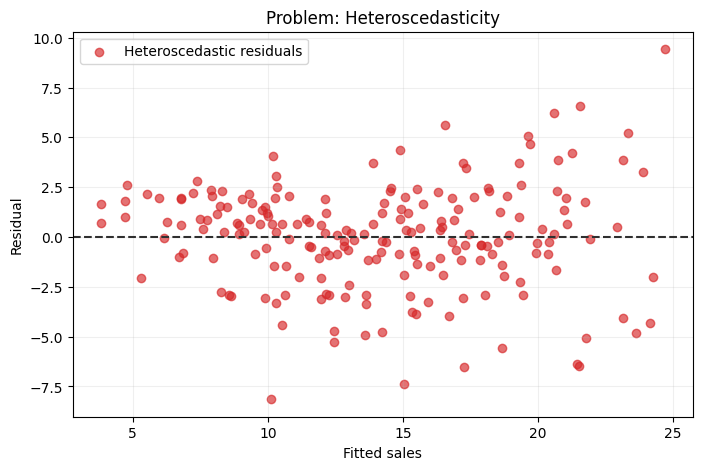

Breusch-Pagan p-value: 0.00039497


In [20]:
tv_scaled_for_noise = (df["tv"].to_numpy() - df["tv"].min()) / (
    df["tv"].max() - df["tv"].min()
)

sigma_hetero = 0.25 + 3.0 * tv_scaled_for_noise
hetero_noise = rng.normal(0, sigma_hetero)

y_hetero = df["sales"].to_numpy() + hetero_noise

X_hetero = sm.add_constant(df[["tv", "radio", "newspaper"]])
ols_hetero = sm.OLS(y_hetero, X_hetero).fit()

pred_hetero = ols_hetero.fittedvalues
res_hetero = ols_hetero.resid

bp_problem = het_breuschpagan(res_hetero, X_hetero)

plt.figure(figsize=(8, 5))
plt.scatter(
    pred_hetero,
    res_hetero,
    color=COLORS["problem"],
    alpha=0.65,
    label="Heteroscedastic residuals"
)
plt.axhline(0, color=COLORS["dark"], linestyle="--")
plt.xlabel("Fitted sales")
plt.ylabel("Residual")
plt.title("Problem: Heteroscedasticity")
plt.legend()
plt.grid(alpha=0.20)
plt.show()

print(f"Breusch-Pagan p-value: {bp_problem[1]:.8f}")

## Solution to Heteroscedasticity

Possible remedies:

->>Transform the target, e.g. log transformation when appropriate.


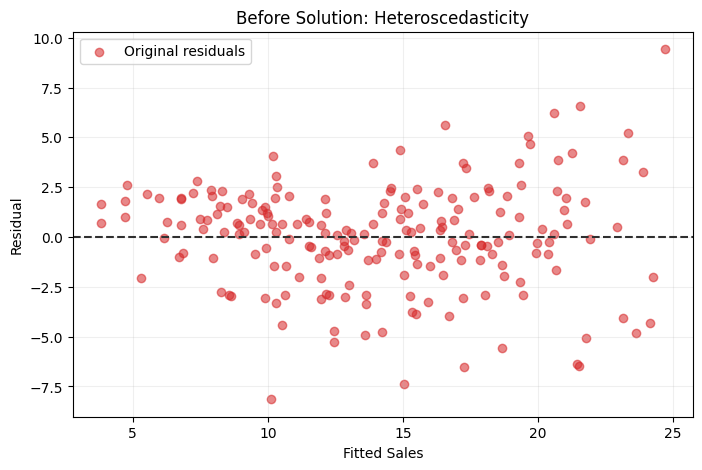

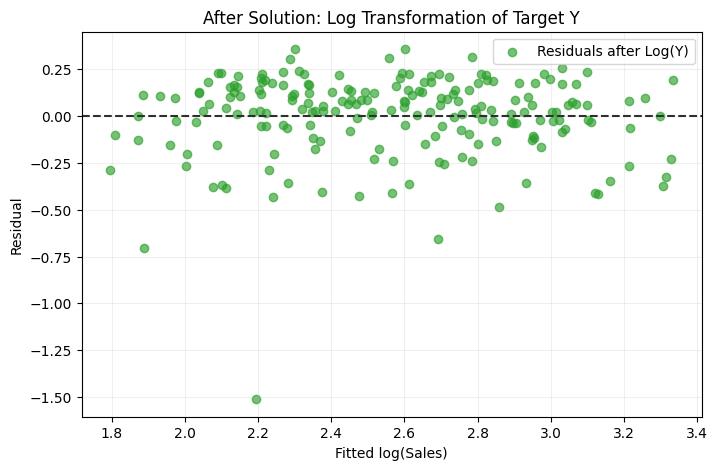

In [21]:
# ----------------------------------------------------------
# Solution for Heteroscedasticity:
# Log Transformation of the Target Variable Y
# ----------------------------------------------------------

# Log transformation requires positive target values.
# If Y contains zero or negative values, shift it slightly.

if np.min(y_hetero) <= 0:
    shift = 1 - np.min(y_hetero)
else:
    shift = 0

y_hetero_positive = y_hetero + shift

# Transform the target variable
log_y_hetero = np.log(y_hetero_positive)


# ----------------------------------------------------------
# Fit Linear Regression on log(Y)
# ----------------------------------------------------------

log_model = sm.OLS(
    log_y_hetero,
    X_hetero
).fit()


# Predictions in log(Y) scale
pred_log = log_model.predict(X_hetero)

# Residuals in log(Y) scale
res_log = log_y_hetero - pred_log


# ----------------------------------------------------------
# BEFORE TRANSFORMATION
# ----------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    pred_hetero,
    res_hetero,
    color=COLORS["problem"],
    alpha=0.55,
    label="Original residuals"
)

plt.axhline(
    0,
    color=COLORS["dark"],
    linestyle="--"
)

plt.xlabel("Fitted Sales")

plt.ylabel("Residual")

plt.title(
    "Before Solution: Heteroscedasticity"
)

plt.legend()

plt.grid(alpha=0.20)

plt.show()


# ----------------------------------------------------------
# AFTER LOG TRANSFORMATION
# ----------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    pred_log,
    res_log,
    color=COLORS["solution"],
    alpha=0.65,
    label="Residuals after Log(Y)"
)

plt.axhline(
    0,
    color=COLORS["dark"],
    linestyle="--"
)

plt.xlabel("Fitted log(Sales)")

plt.ylabel("Residual")

plt.title(
    "After Solution: Log Transformation of Target Y"
)

plt.legend()

plt.grid(alpha=0.20)

plt.show()

# Assumption 5 — No Severe Multicollinearity

## Assumption

Predictors should not be nearly exact linear combinations of one another.

Example:
$$
[
TV_{copy} \approx TV
]
$$
## Why is multicollinearity a problem?

The model may still predict well, but:

- coefficients can become unstable,
- coefficient signs can become surprising,
- standard errors can become large,
- interpretation becomes difficult.

## Diagnostics

1. Correlation matrix
2. **Variance Inflation Factor (VIF)**

A very large VIF indicates that a predictor can be strongly explained by the other predictors.

### VIF rule of thumb
$$
[
VIF_j=\frac{1}{1-R_j^2}
]
$$
where $R_j^2$ comes from predicting feature $X_j$ using the other predictors.

A common practical warning range is **VIF above about 5–10**, but context matters. Severe collinearity stretches the RSS valley, so many coefficient combinations can produce nearly the same loss while individual standard errors become large.


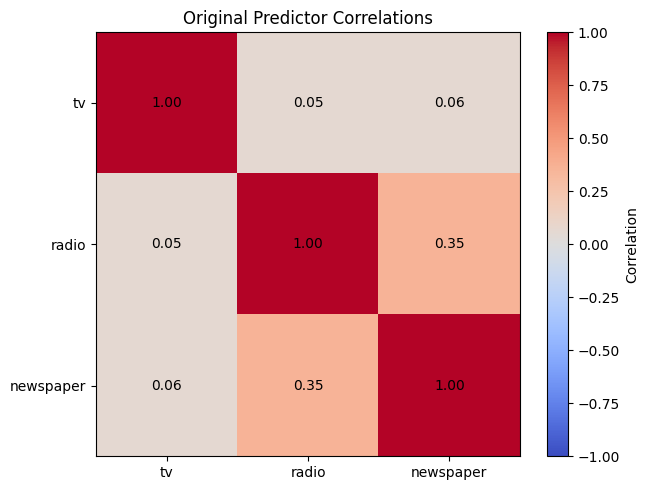

In [22]:
corr_original = df[["tv", "radio", "newspaper"]].corr()

plt.figure(figsize=(6.5, 5))
plt.imshow(
    corr_original,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.colorbar(label="Correlation")

labels = corr_original.columns.tolist()
plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(labels)), labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(
            j, i,
            f"{corr_original.iloc[i,j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Original Predictor Correlations")
plt.tight_layout()
plt.show()

In [23]:
def compute_vif(X_df):
    X_num = X_df.astype(float).copy()
    X_const = sm.add_constant(X_num)

    rows = []
    for i, col in enumerate(X_const.columns):
        if col == "const":
            continue

        rows.append({
            "Feature": col,
            "VIF": variance_inflation_factor(X_const.values, i)
        })

    return pd.DataFrame(rows)

vif_original = compute_vif(df[["tv", "radio", "newspaper"]])
vif_original

,Feature,VIF
0,tv,1.0046
1,radio,1.1450
2,newspaper,1.1452


## Controlled Multicollinearity Violation

We create:
$$
[
TV_{copy}
=
0.98(TV) + small\ noise
]
$$
The duplicate feature contains almost the same information as TV.

,Feature,VIF
0,tv,"11,122.7307"
1,radio,1.1539
2,newspaper,1.1884
3,tv_copy,"11,124.1551"


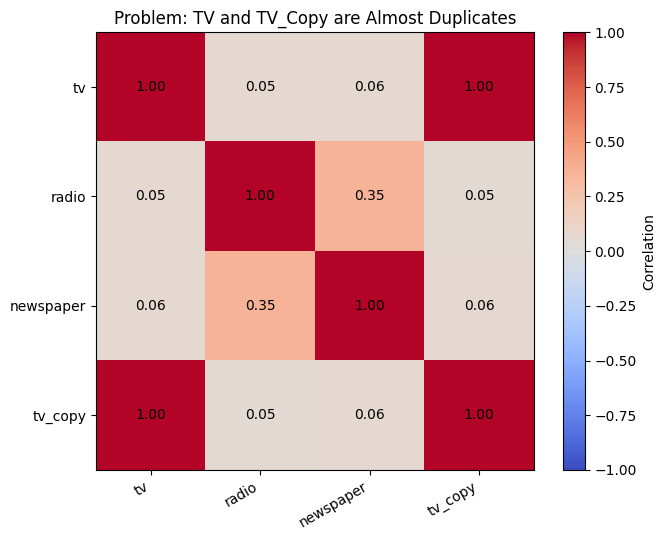

In [24]:
df_multi = df.copy()

df_multi["tv_copy"] = (
    0.98 * df_multi["tv"]
    + rng.normal(0, 0.8, len(df_multi))
)

vif_problem = compute_vif(
    df_multi[["tv", "radio", "newspaper", "tv_copy"]]
)

display(vif_problem)

corr_problem = df_multi[["tv", "radio", "newspaper", "tv_copy"]].corr()

plt.figure(figsize=(7, 5.5))
plt.imshow(
    corr_problem,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.colorbar(label="Correlation")

labels = corr_problem.columns.tolist()
plt.xticks(range(len(labels)), labels, rotation=30, ha="right")
plt.yticks(range(len(labels)), labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(
            j, i,
            f"{corr_problem.iloc[i,j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Problem: TV and TV_Copy are Almost Duplicates")
plt.tight_layout()
plt.show()

In [25]:
# Compare coefficients with and without the redundant feature
model_original_coef = LinearRegression().fit(
    df[["tv", "radio", "newspaper"]],
    df["sales"]
)

model_multi_coef = LinearRegression().fit(
    df_multi[["tv", "radio", "newspaper", "tv_copy"]],
    df_multi["sales"]
)

coef_problem = pd.DataFrame({
    "Feature": ["tv", "radio", "newspaper", "tv_copy"],
    "Coefficient_with_multicollinearity": model_multi_coef.coef_
})

display(coef_problem)

print("\nOriginal model coefficients:")
display(pd.DataFrame({
    "Feature": ["tv", "radio", "newspaper"],
    "Original_coefficient": model_original_coef.coef_
}))

,Feature,Coefficient_with_multicollinearity
0,tv,-0.0663
1,radio,0.1891
2,newspaper,-0.0019
3,tv_copy,0.1144



Original model coefficients:


,Feature,Original_coefficient
0,tv,0.0458
1,radio,0.1885
2,newspaper,-0.0010


## Solution to Multicollinearity

Possible solutions:

1. Remove one of two redundant variables.
2. Combine highly related variables if scientifically meaningful.
3. Use regularization such as Ridge when prediction is the main goal.

For this teaching example, the correct simple solution is:

> **Remove `tv_copy` because it was artificially created from TV and adds no new information.**

VIF before removing redundant variable:


,Feature,VIF
0,tv,"11,122.7307"
1,radio,1.1539
2,newspaper,1.1884
3,tv_copy,"11,124.1551"



VIF after removing TV_Copy:


,Feature,VIF
0,tv,1.0046
1,radio,1.1450
2,newspaper,1.1452


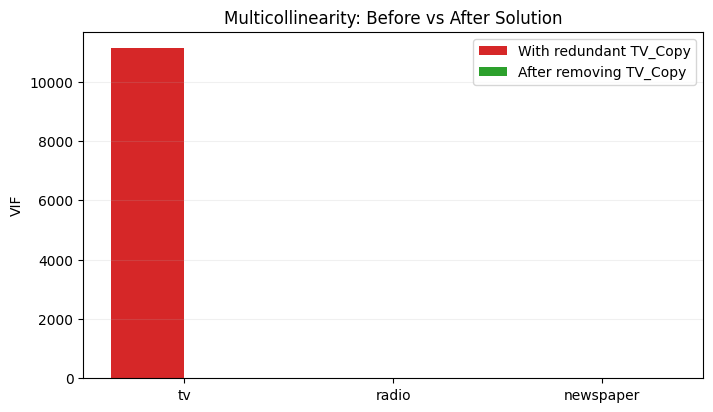

In [26]:
vif_fixed = compute_vif(df_multi[["tv", "radio", "newspaper"]])

print("VIF before removing redundant variable:")
display(vif_problem)

print("\nVIF after removing TV_Copy:")
display(vif_fixed)

plt.figure(figsize=(8, 4.5))

problem_vals = vif_problem.set_index("Feature")["VIF"]
fixed_vals = vif_fixed.set_index("Feature")["VIF"]

features_vif = ["tv", "radio", "newspaper"]

x = np.arange(len(features_vif))
width = 0.35

plt.bar(
    x - width/2,
    [problem_vals[f] for f in features_vif],
    width,
    color=COLORS["problem"],
    label="With redundant TV_Copy"
)

plt.bar(
    x + width/2,
    [fixed_vals[f] for f in features_vif],
    width,
    color=COLORS["solution"],
    label="After removing TV_Copy"
)

plt.xticks(x, features_vif)
plt.ylabel("VIF")
plt.title("Multicollinearity: Before vs After Solution")
plt.legend()
plt.grid(axis="y", alpha=0.18)
plt.show()

# Assumption 6 — No Extreme Influential Outliers

## Problem

OLS minimizes squared error:
$$
[
\sum (y_i-\hat y_i)^2
]
$$
Therefore, a very large residual receives a very large penalty.

A few extreme observations can pull the fitted line toward themselves.

## Important rule

**Do not automatically delete every outlier.**

First ask:

1. Is it a data-entry error?
2. Is it a measurement error?
3. Is it a legitimate but rare case?
4. Does it represent a different population?

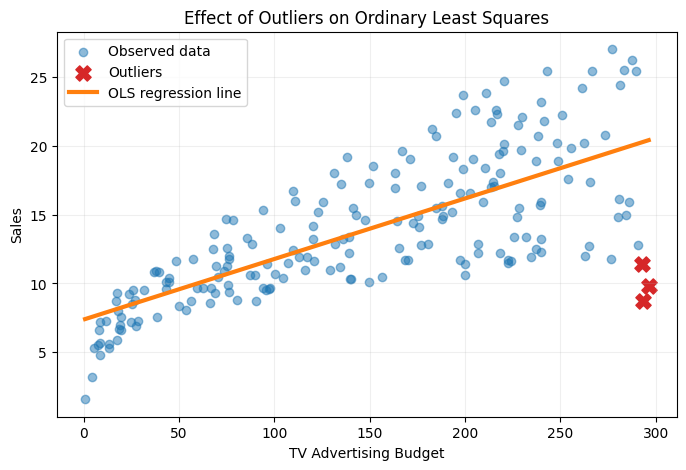

OLS Intercept : 7.3847
OLS Slope     : 0.0439


In [27]:
# ----------------------------------------------------------
# Outlier Example using Ordinary Least Squares (OLS)
# ----------------------------------------------------------

# Use TV only so the effect can be clearly visualized
x_out = df["tv"].to_numpy().copy()
y_out_clean = df["sales"].to_numpy().copy()

# Create a copy of the target
y_out_problem = y_out_clean.copy()

# ----------------------------------------------------------
# Inject some artificial outliers
# ----------------------------------------------------------

outlier_indices = np.argsort(x_out)[-3:]

y_out_problem[outlier_indices] = (
    y_out_problem[outlier_indices]
    - np.array([10, 12, 14])
)


# ----------------------------------------------------------
# Fit Ordinary Least Squares Linear Regression
# ----------------------------------------------------------

ols_out = LinearRegression()

ols_out.fit(
    x_out.reshape(-1, 1),
    y_out_problem
)

pred_ols_out = ols_out.predict(
    x_out.reshape(-1, 1)
)


# Sort X only for drawing a clean regression line
order = np.argsort(x_out)


# ----------------------------------------------------------
# Visualization
# ----------------------------------------------------------

plt.figure(figsize=(8, 5))

# Normal observations
plt.scatter(
    x_out,
    y_out_problem,
    color=COLORS["data"],
    alpha=0.50,
    label="Observed data"
)

# Highlight the artificial outliers
plt.scatter(
    x_out[outlier_indices],
    y_out_problem[outlier_indices],
    color=COLORS["problem"],
    s=120,
    marker="X",
    label="Outliers"
)

# OLS regression line
plt.plot(
    x_out[order],
    pred_ols_out[order],
    color=COLORS["fit"],
    linewidth=3,
    label="OLS regression line"
)

plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")

plt.title(
    "Effect of Outliers on Ordinary Least Squares"
)

plt.legend()
plt.grid(alpha=0.20)

plt.show()


# ----------------------------------------------------------
# Model Parameters
# ----------------------------------------------------------

print(
    f"OLS Intercept : {ols_out.intercept_:.4f}"
)

print(
    f"OLS Slope     : {ols_out.coef_[0]:.4f}"
)

## Solution to Influential Outliers

Possible actions:

- Correct the observation if it is a known error.
- Remove it only with a defensible reason.
- Add missing explanatory variables if the point is unusual for a valid reason.
- Transform the data when appropriate.


#Assumption 6  Failure Mode — High-Leverage Points

An **outlier** and a **high-leverage point** are not the same thing.

- **Outlier:** unusual response value $Y$ relative to what the model predicts.
- **High leverage:** unusual predictor location $X$ relative to the rest of the dataset.

For OLS, fitted values can be written as
$$
[
\hat y=Hy,
\qquad
H=X(X^TX)^{-1}X^T.
]
$$
The diagonal element
$$
[
h_i=H_{ii}
]
$$
is the leverage of observation $i$.

The average leverage is
$$
[
\frac{p+1}{N}.
]
$$
A point can have high leverage even when its residual is small. A point becomes especially influential when it combines unusual predictors with a large residual.

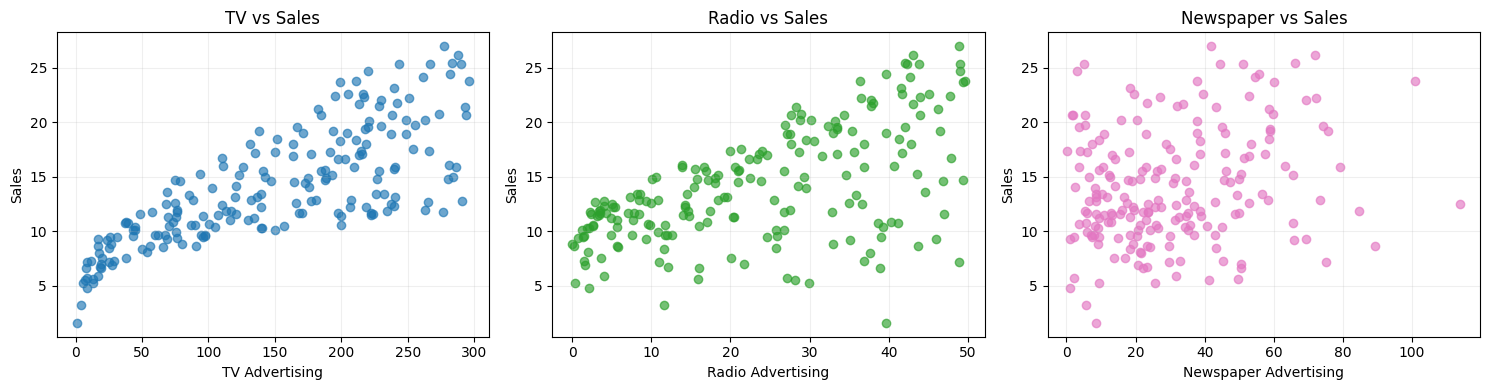

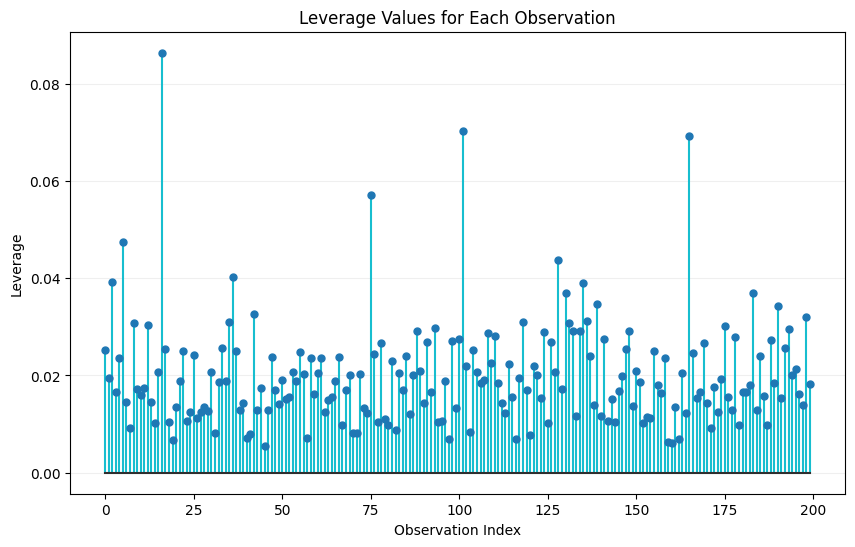

In [28]:
# ----------------------------------------------------------
# High-Leverage Point Detection
# Advertising Dataset
# ----------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from statsmodels.stats.outliers_influence import OLSInfluence


# ----------------------------------------------------------
# Step 1: Prepare the predictors and target
# ----------------------------------------------------------

X = df[['tv', 'radio', 'newspaper']]
y = df['sales']


# ----------------------------------------------------------
# Step 2: Visualize predictors against Sales
# ----------------------------------------------------------

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.scatter(
    df['tv'],
    df['sales'],
    color=COLORS["data"],
    alpha=0.65
)
plt.xlabel('TV Advertising')
plt.ylabel('Sales')
plt.title('TV vs Sales')
plt.grid(alpha=0.20)


plt.subplot(1, 3, 2)
plt.scatter(
    df['radio'],
    df['sales'],
    color=COLORS["solution"],
    alpha=0.65
)
plt.xlabel('Radio Advertising')
plt.ylabel('Sales')
plt.title('Radio vs Sales')
plt.grid(alpha=0.20)


plt.subplot(1, 3, 3)
plt.scatter(
    df['newspaper'],
    df['sales'],
    color=COLORS["accent"],
    alpha=0.65
)
plt.xlabel('Newspaper Advertising')
plt.ylabel('Sales')
plt.title('Newspaper vs Sales')
plt.grid(alpha=0.20)


plt.tight_layout()
plt.show()


# ----------------------------------------------------------
# Step 3: Add the intercept term
# ----------------------------------------------------------

X = sm.add_constant(X)


# ----------------------------------------------------------
# Step 4: Fit the OLS Linear Regression model
# ----------------------------------------------------------

model = sm.OLS(
    y,
    X
).fit()


# ----------------------------------------------------------
# Step 5: Calculate leverage values
# ----------------------------------------------------------

influence = OLSInfluence(model)

leverage = influence.hat_matrix_diag


# Add leverage values to the dataframe
df_leverage = df.copy()

df_leverage['Leverage'] = leverage


# ----------------------------------------------------------
# Step 6: Plot leverage values
# ----------------------------------------------------------

plt.figure(figsize=(10, 6))

markerline, stemlines, baseline = plt.stem(
    np.arange(len(leverage)),
    leverage
)

plt.setp(
    markerline,
    color=COLORS["data"],
    markersize=5
)

plt.setp(
    stemlines,
    color=COLORS["secondary"]
)

plt.setp(
    baseline,
    color=COLORS["dark"]
)

plt.xlabel('Observation Index')
plt.ylabel('Leverage')
plt.title('Leverage Values for Each Observation')

plt.grid(
    axis='y',
    alpha=0.20
)

plt.show()

In [29]:
# ----------------------------------------------------------
# Step 7: Define a threshold for high leverage
# ----------------------------------------------------------

n = len(df)

# Number of predictors
p = 3

# Average leverage
average_leverage = (p + 1) / n

# Common teaching threshold
high_leverage_threshold = 2 * average_leverage


print(
    f"Average leverage = {average_leverage:.4f}"
)

print(
    f"High leverage threshold = {high_leverage_threshold:.4f}"
)

Average leverage = 0.0200
High leverage threshold = 0.0400


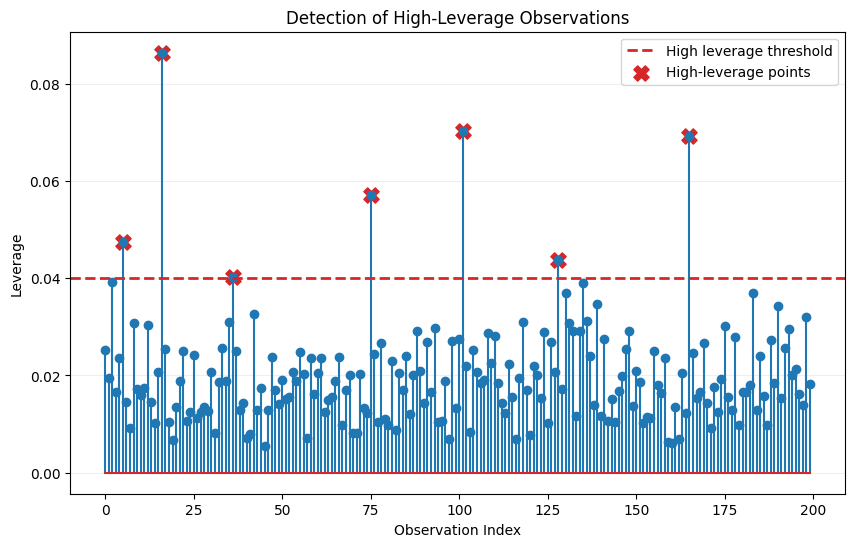

High-leverage observation indices:
[  5  16  36  75 101 128 165]


In [30]:
# ----------------------------------------------------------
# Step 8: Highlight high-leverage observations
# ----------------------------------------------------------

high_leverage_points = np.where(
    leverage > high_leverage_threshold
)[0]


plt.figure(figsize=(10, 6))

plt.stem(
    np.arange(len(leverage)),
    leverage,
    markerfmt="o"
)


plt.axhline(
    high_leverage_threshold,
    color=COLORS["problem"],
    linestyle="--",
    linewidth=2,
    label="High leverage threshold"
)


plt.scatter(
    high_leverage_points,
    leverage[high_leverage_points],
    color=COLORS["problem"],
    marker="X",
    s=120,
    label="High-leverage points"
)


plt.xlabel('Observation Index')

plt.ylabel('Leverage')

plt.title(
    'Detection of High-Leverage Observations'
)

plt.legend()

plt.grid(
    axis='y',
    alpha=0.20
)

plt.show()


print(
    "High-leverage observation indices:"
)

print(
    high_leverage_points
)

# PART B — LINEAR REGRESSION FROM SCRATCH USING MATRICES

From this point onward, the **from-scratch model uses matrix operations only**.

We use all three predictors:

- TV advertising
- Radio advertising
- Newspaper advertising

The model is
$$
[
\hat y
=
\beta_0
+
\beta_1x_{TV}
+
\beta_2x_{Radio}
+
\beta_3x_{Newspaper}
]
$$
Instead of writing one equation for every observation, write the entire dataset in matrix form:
$$
[
\boxed{
\mathbf y = X\boldsymbol{\beta}+\boldsymbol{\varepsilon}
}
]
$$
where
$$
[
X=
\begin{bmatrix}
1 & x_{11} & x_{12} & x_{13}\\
1 & x_{21} & x_{22} & x_{23}\\
\vdots & \vdots & \vdots & \vdots\\
1 & x_{n1} & x_{n2} & x_{n3}
\end{bmatrix}
]
$$
and
$$
[
\boldsymbol{\beta}
=
\begin{bmatrix}
\beta_0\\
\beta_1\\
\beta_2\\
\beta_3
\end{bmatrix},
\qquad
\mathbf y
=
\begin{bmatrix}
y_1\\
y_2\\
\vdots\\
y_n
\end{bmatrix}.
]
$$
For this dataset:

- \(X\) has \(n\) rows and \(4\) columns.
- Column 1 contains only ones for the intercept.
- Columns 2–4 contain TV, Radio, and Newspaper.
- \(\boldsymbol{\beta}\) is a \(4\times1\) parameter vector.
- \(\mathbf y\) is an \(n\times1\) target vector.

The prediction for **all observations at once** is
$$
[
\boxed{
\hat{\mathbf y}=X\boldsymbol{\beta}
}
]
$$
This matrix equation will be used in all three from-scratch methods.

## Least-Squares Objective in Matrix Form

The residual vector is
$$
[
\mathbf e
=
\hat{\mathbf y}-\mathbf y
=
X\boldsymbol{\beta}-\mathbf y.
]
$$
The least-squares objective is
$$
[
\boxed{
J(\boldsymbol{\beta})
=
\frac{1}{2n}
(X\boldsymbol{\beta}-\mathbf y)^T
(X\boldsymbol{\beta}-\mathbf y)
}
]
$$
The factor \(1/(2n)\) is convenient for optimization. It does **not** change the location of the minimum.

The goal is therefore:
$$
[
\boxed{
\text{Find }\boldsymbol{\beta}
\text{ that minimizes }J(\boldsymbol{\beta})
}
]
$$
We will solve exactly the same objective in three ways:

1. **Closed Form / Normal Equation**
2. **Gradient Descent**
3. **Newton / Hessian Method**

Only the optimization strategy changes.

# 6. Prepare Train and Test Data

For the from-scratch model, we do not use a regression library to construct the model.

We first create:
$$
[
X=
\begin{bmatrix}
TV & Radio & Newspaper
\end{bmatrix}
]
$$
and
$$
[
\mathbf y=
\begin{bmatrix}
Sales
\end{bmatrix}.
]
$$
The train/test split is created using shuffled NumPy indices so that the model-building section remains independent of `scikit-learn`.

In [31]:
# ----------------------------------------------------------
# Prepare X and y
# ----------------------------------------------------------

X_features = df[
    ["tv", "radio", "newspaper"]
].to_numpy(dtype=float)

y_target = df[
    ["sales"]
].to_numpy(dtype=float)

# ----------------------------------------------------------
# Manual train/test split using NumPy
# ----------------------------------------------------------

rng = np.random.default_rng(42)

indices = np.arange(
    X_features.shape[0]
)

rng.shuffle(indices)

split_index = int(
    0.80 * len(indices)
)

train_idx = indices[:split_index]
test_idx = indices[split_index:]

X_train_raw = X_features[train_idx]
X_test_raw = X_features[test_idx]

y_train = y_target[train_idx]
y_test = y_target[test_idx]

print("X_train_raw shape:", X_train_raw.shape)
print("X_test_raw shape :", X_test_raw.shape)
print("y_train shape     :", y_train.shape)
print("y_test shape      :", y_test.shape)

X_train_raw shape: (160, 3)
X_test_raw shape : (40, 3)
y_train shape     : (160, 1)
y_test shape      : (40, 1)


# 7. Standardize the Predictors

The three predictors have different numerical scales.

Gradient-based optimization is easier when predictors are on comparable scales.

For each predictor \(j\),
$$
[
z_{ij}
=
\frac{x_{ij}-\mu_j}{\sigma_j}
]
$$
where \(\mu_j\) and \(\sigma_j\) are calculated from the **training data only**.

In vector form:
$$
[
\boxed{
X_{scaled}
=
\frac{X-\boldsymbol{\mu}}
{\boldsymbol{\sigma}}
}
]
$$
The same training mean and standard deviation are applied to the test set.

After standardization, an intercept column of ones is added:
$$
[
X_{design}
=
\begin{bmatrix}
1 & z_{11} & z_{12} & z_{13}\\
1 & z_{21} & z_{22} & z_{23}\\
\vdots & \vdots & \vdots & \vdots
\end{bmatrix}.
]
$$

In [32]:
# ----------------------------------------------------------
# Standardize predictors
# ----------------------------------------------------------

feature_mean = X_train_raw.mean(
    axis=0
)

feature_std = X_train_raw.std(
    axis=0
)

X_train_scaled = (
    X_train_raw - feature_mean
) / feature_std

X_test_scaled = (
    X_test_raw - feature_mean
) / feature_std

# ----------------------------------------------------------
# Add intercept column
# ----------------------------------------------------------

X_train = np.column_stack(
    (
        np.ones(
            (X_train_scaled.shape[0], 1)
        ),
        X_train_scaled
    )
)

X_test = np.column_stack(
    (
        np.ones(
            (X_test_scaled.shape[0], 1)
        ),
        X_test_scaled
    )
)

print("Design matrix X_train shape:", X_train.shape)
print("Design matrix X_test shape :", X_test.shape)

print("\nFirst five rows of X_train:")
print(X_train[:5])

Design matrix X_train shape: (160, 4)
Design matrix X_test shape : (40, 4)

First five rows of X_train:
[[ 1.          0.67978855  0.06028691 -0.77872155]
 [ 1.          0.03575588  0.46219966 -0.85385259]
 [ 1.         -0.76251496  0.84401676  1.02911924]
 [ 1.         -0.59061593 -0.83731822  0.23085188]
 [ 1.         -1.13927996  0.28803747  0.20267773]]


# 8. Method 1 — Closed Form / Normal Equation

Start with the least-squares objective:
$$
[
J(\boldsymbol{\beta})
=
\frac{1}{2n}
(X\boldsymbol{\beta}-\mathbf y)^T
(X\boldsymbol{\beta}-\mathbf y).
]
$$
Differentiate with respect to the complete parameter vector:
$$
[
\nabla_{\beta}J
=
\frac{1}{n}
X^T(X\boldsymbol{\beta}-\mathbf y).
]
$$
At the minimum,
$$
[
\nabla_{\beta}J=0.
]
$$
Therefore,
$$
[
X^T(X\boldsymbol{\beta}-\mathbf y)=0.
]
$$
Expanding:
$$
[
X^TX\boldsymbol{\beta}=X^T\mathbf y.
]
$$
These are the **Normal Equations**.

If \(X^TX\) is invertible,
$$
[
\boxed{
\hat{\boldsymbol{\beta}}
=
(X^TX)^{-1}X^T\mathbf y
}
]
$$
This gives the least-squares solution directly.

> In this lab we explicitly use the inverse because the purpose is to visualize the mathematical expression. In production numerical software, direct inversion is usually avoided in favor of more numerically stable solvers.

In [33]:
# ----------------------------------------------------------
# CLOSED FORM / NORMAL EQUATION — MATRIX FORM
# beta = (X^T X)^(-1) X^T y
# ----------------------------------------------------------

XT_X = X_train.T @ X_train

XT_y = X_train.T @ y_train

beta_closed = (
    np.linalg.inv(XT_X)
    @ XT_y
)

# Matrix predictions
pred_closed_train = (
    X_train @ beta_closed
)

pred_closed_test = (
    X_test @ beta_closed
)

parameter_names = [
    "Intercept",
    "TV",
    "Radio",
    "Newspaper"
]

print("Closed-form parameter vector:\n")

for name, value in zip(
    parameter_names,
    beta_closed.ravel()
):
    print(
        f"{name:<12}: {value:.6f}"
    )

Closed-form parameter vector:

Intercept   : 13.487500
TV          : 3.937740
Radio       : 2.619737
Newspaper   : 0.023082


## Verify the Normal-Equation Orthogonality Condition

At the least-squares optimum,
$$
[
\boxed{
X^T(\mathbf y-X\hat{\boldsymbol{\beta}})=0
}
]
$$
or equivalently,
$$
[
X^T\mathbf e=0.
]
$$
This means that the residual vector is orthogonal to every column of the design matrix.

We can verify this numerically.

In [34]:
# Residual vector
residual_closed_train = (
    y_train - pred_closed_train
)

# Orthogonality check
normal_equation_check = (
    X_train.T
    @ residual_closed_train
)

print("X^T e =")
print(normal_equation_check)

print(
    "\nValues should be approximately zero "
    "(up to floating-point precision)."
)

X^T e =
[[-1.38555833e-13]
 [-2.70894418e-13]
 [ 1.99840144e-14]
 [ 3.24185123e-14]]

Values should be approximately zero (up to floating-point precision).


# 9. Method 2 — First-Order Optimization: Gradient Descent

The Closed Form jumps directly to the optimum.

Gradient Descent reaches the same solution iteratively.

The prediction vector is
$$
[
\hat{\mathbf y}
=
X\boldsymbol{\beta}.
]
$$
The error vector is
$$
[
\mathbf e
=
X\boldsymbol{\beta}-\mathbf y.
]
$$
The loss is
$$
[
J(\boldsymbol{\beta})
=
\frac{1}{2n}
\mathbf e^T\mathbf e.
]
$$
The gradient is
$$
[
\boxed{
\nabla_{\beta}J
=
\frac{1}{n}
X^T(X\boldsymbol{\beta}-\mathbf y)
}
]
$$
and the complete parameter vector is updated simultaneously:
$$
[
\boxed{
\boldsymbol{\beta}_{t+1}
=
\boldsymbol{\beta}_{t}
-
\alpha
\nabla_{\beta}J
}
]
$$
where \(\alpha\) is the learning rate.

Notice that there is **no separate code for the intercept, TV, Radio, or Newspaper coefficient**. They are all updated together through the parameter vector \(\boldsymbol{\beta}\).

In [35]:
# ----------------------------------------------------------
# GRADIENT DESCENT — MATRIX FORM
# ----------------------------------------------------------

def gradient_descent_matrix(
    X,
    y,
    learning_rate=0.08,
    epochs=2000
):
    n = X.shape[0]

    # Parameter vector:
    # one value for each column of X
    beta = np.zeros(
        (X.shape[1], 1)
    )

    loss_history = []

    for epoch in range(epochs):

        # Prediction:
        # y_hat = X beta
        y_hat = (
            X @ beta
        )

        # Error vector
        error = (
            y_hat - y
        )

        # J(beta) = 1/(2n) * e^T e
        loss = (
            error.T @ error
        ) / (2 * n)

        loss_history.append(
            loss.item()
        )

        # Gradient:
        # (1/n) X^T (X beta - y)
        gradient = (
            X.T @ error
        ) / n

        # Matrix/vector update
        beta = (
            beta
            -
            learning_rate
            * gradient
        )

    return beta, loss_history


beta_gd, gd_loss = gradient_descent_matrix(
    X_train,
    y_train,
    learning_rate=0.08,
    epochs=2000
)

pred_gd_train = (
    X_train @ beta_gd
)

pred_gd_test = (
    X_test @ beta_gd
)

print("Gradient Descent parameter vector:\n")

for name, value in zip(
    parameter_names,
    beta_gd.ravel()
):
    print(
        f"{name:<12}: {value:.6f}"
    )

print(
    f"\nFinal cost: {gd_loss[-1]:.10f}"
)

Gradient Descent parameter vector:

Intercept   : 13.487500
TV          : 3.937740
Radio       : 2.619737
Newspaper   : 0.023082

Final cost: 1.4472348000


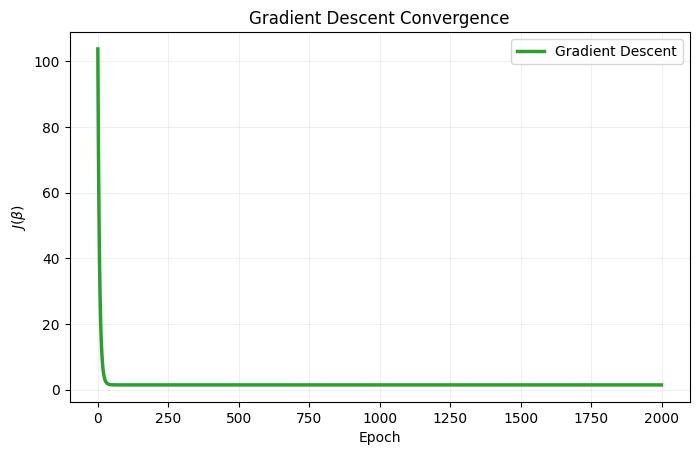

In [36]:
# ----------------------------------------------------------
# Gradient Descent convergence
# ----------------------------------------------------------

plt.figure(figsize=(8, 4.8))

plt.plot(
    gd_loss,
    color=COLORS["solution"],
    linewidth=2.5,
    label="Gradient Descent"
)

plt.xlabel("Epoch")
plt.ylabel(r"$J(\beta)$")
plt.title(
    "Gradient Descent Convergence"
)

plt.legend()
plt.grid(alpha=0.20)
plt.show()

## Effect of the Learning Rate

The matrix update is
$$
[
\boldsymbol{\beta}_{t+1}
=
\boldsymbol{\beta}_{t}
-
\alpha\nabla J.
]
$$
Therefore:

- a very small \(\alpha\) produces slow progress,
- a suitable \(\alpha\) converges smoothly,
- an excessively large \(\alpha\) can overshoot or diverge.

The following experiment uses the **same matrix Gradient Descent algorithm** with several learning rates.

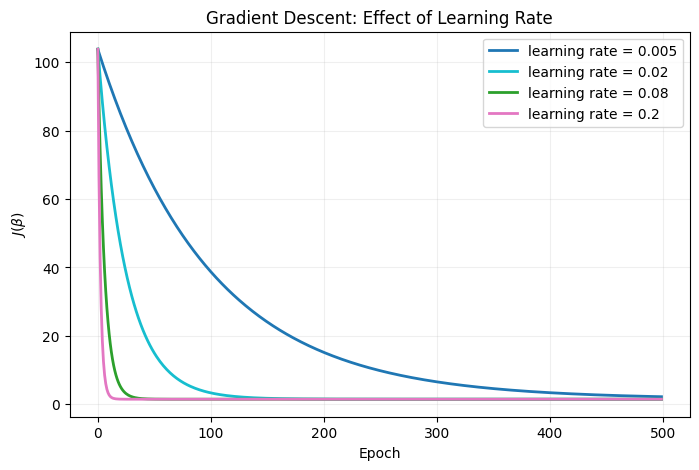

In [37]:
learning_rate_settings = [
    (0.005, COLORS["data"]),
    (0.02, COLORS["secondary"]),
    (0.08, COLORS["solution"]),
    (0.20, COLORS["accent"])
]

plt.figure(figsize=(8, 5))

for lr, color in learning_rate_settings:

    _, history = gradient_descent_matrix(
        X_train,
        y_train,
        learning_rate=lr,
        epochs=500
    )

    plt.plot(
        history,
        color=color,
        linewidth=2,
        label=f"learning rate = {lr}"
    )

plt.xlabel("Epoch")
plt.ylabel(r"$J(\beta)$")
plt.title(
    "Gradient Descent: Effect of Learning Rate"
)

plt.legend()
plt.grid(alpha=0.20)
plt.show()

# 10. Method 3 — Second-Order Optimization: Newton / Hessian Method

Gradient Descent uses only the first derivative.

Newton's method also uses the **second derivative**, represented by the Hessian matrix.

For least-squares Linear Regression,
$$
[
\nabla_{\beta}J
=
\frac{1}{n}
X^T(X\boldsymbol{\beta}-\mathbf y)
]
$$
and
$$
[
\boxed{
H
=
\nabla_{\beta}^2J
=
\frac{1}{n}X^TX
}
]
$$
The Newton update is
$$
[
\boxed{
\boldsymbol{\beta}_{t+1}
=
\boldsymbol{\beta}_{t}
-
H^{-1}
\nabla_{\beta}J
}
]
$$
For Ordinary Least Squares, the objective is quadratic and the Hessian is constant.

Therefore, with an exact Hessian and full Newton step, the optimum is reached essentially in **one update**, apart from floating-point error.

In [38]:
# ----------------------------------------------------------
# NEWTON / HESSIAN METHOD — MATRIX FORM
# ----------------------------------------------------------

def newton_matrix(
    X,
    y,
    iterations=3
):
    n = X.shape[0]

    beta = np.zeros(
        (X.shape[1], 1)
    )

    loss_history = []

    # Hessian is constant for OLS
    H = (
        X.T @ X
    ) / n

    H_inv = np.linalg.inv(H)

    # Save the initial loss
    initial_error = (
        X @ beta - y
    )

    initial_loss = (
        initial_error.T
        @ initial_error
    ) / (2 * n)

    loss_history.append(
        initial_loss.item()
    )

    for iteration in range(iterations):

        # Error
        error = (
            X @ beta - y
        )

        # Gradient
        gradient = (
            X.T @ error
        ) / n

        # Newton update
        beta = (
            beta
            -
            H_inv @ gradient
        )

        # Loss after update
        new_error = (
            X @ beta - y
        )

        new_loss = (
            new_error.T
            @ new_error
        ) / (2 * n)

        loss_history.append(
            new_loss.item()
        )

    return beta, loss_history


beta_newton, newton_loss = newton_matrix(
    X_train,
    y_train,
    iterations=3
)

pred_newton_train = (
    X_train @ beta_newton
)

pred_newton_test = (
    X_test @ beta_newton
)

print("Newton/Hessian parameter vector:\n")

for name, value in zip(
    parameter_names,
    beta_newton.ravel()
):
    print(
        f"{name:<12}: {value:.6f}"
    )

print("\nLoss history:")

for step, value in enumerate(
    newton_loss
):
    print(
        f"Step {step}: {value:.10f}"
    )

Newton/Hessian parameter vector:

Intercept   : 13.487500
TV          : 3.937740
Radio       : 2.619737
Newspaper   : 0.023082

Loss history:
Step 0: 103.8170625000
Step 1: 1.4472348000
Step 2: 1.4472348000
Step 3: 1.4472348000


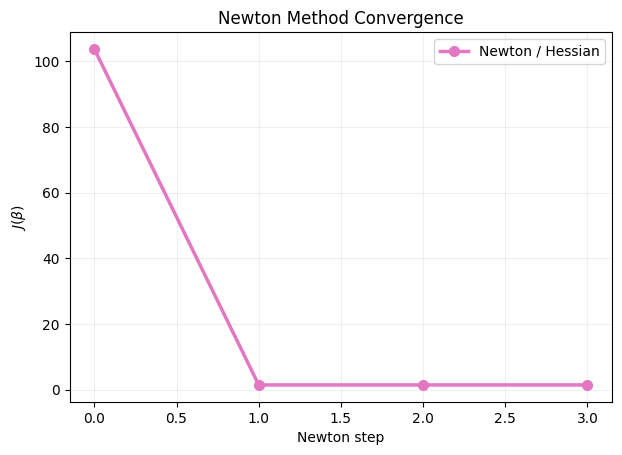

In [39]:
plt.figure(figsize=(7, 4.8))

plt.plot(
    range(len(newton_loss)),
    newton_loss,
    marker="o",
    markersize=7,
    color=COLORS["accent"],
    linewidth=2.5,
    label="Newton / Hessian"
)

plt.xlabel("Newton step")
plt.ylabel(r"$J(\beta)$")
plt.title(
    "Newton Method Convergence"
)

plt.legend()
plt.grid(alpha=0.20)
plt.show()

# 12. Evaluation Metrics from Scratch

For every method, predictions are obtained through the same matrix equation:
$$
[
\hat{\mathbf y}
=
X\hat{\boldsymbol{\beta}}.
]
$$
We calculate the evaluation metrics manually.

## Mean Squared Error
$$
[
\boxed{
MSE
=
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-\hat y_i)^2
}
]
$$
## Root Mean Squared Error
$$
[
\boxed{
RMSE
=
\sqrt{MSE}
}
]
$$
## Coefficient of Determination
$$
[
SS_{res}
=
\sum_{i=1}^{n}
(y_i-\hat y_i)^2
]
$$
$$
[
SS_{tot}
=
\sum_{i=1}^{n}
(y_i-\bar y)^2
]
$$
and
$$
[
\boxed{
R^2
=
1-
\frac{SS_{res}}{SS_{tot}}
}
]
$$

In [40]:
# ----------------------------------------------------------
# Evaluation metrics from scratch
# ----------------------------------------------------------

def mse_manual(
    y_true,
    y_pred
):
    error = (
        y_true - y_pred
    )

    return float(
        np.mean(
            error ** 2
        )
    )


def rmse_manual(
    y_true,
    y_pred
):
    return float(
        np.sqrt(
            mse_manual(
                y_true,
                y_pred
            )
        )
    )


def r2_manual(
    y_true,
    y_pred
):
    ss_res = np.sum(
        (y_true - y_pred) ** 2
    )

    ss_tot = np.sum(
        (
            y_true
            - np.mean(y_true)
        ) ** 2
    )

    return float(
        1 - ss_res / ss_tot
    )


def evaluate_manual(
    y_true,
    y_pred
):
    return {
        "MSE": mse_manual(
            y_true,
            y_pred
        ),
        "RMSE": rmse_manual(
            y_true,
            y_pred
        ),
        "R2": r2_manual(
            y_true,
            y_pred
        )
    }


scratch_results = pd.DataFrame([
    {
        "Method": "Closed Form",
        **evaluate_manual(
            y_test,
            pred_closed_test
        )
    },
    {
        "Method": "Gradient Descent",
        **evaluate_manual(
            y_test,
            pred_gd_test
        )
    },
    {
        "Method": "Newton / Hessian",
        **evaluate_manual(
            y_test,
            pred_newton_test
        )
    }
])

scratch_results

,Method,MSE,RMSE,R2
0,Closed Form,2.5304,1.5907,0.9056
1,Gradient Descent,2.5304,1.5907,0.9056
2,Newton / Hessian,2.5304,1.5907,0.9056


## 12.1 Residual Standard Error (RSE)

For multiple Linear Regression with \(p\) predictors,
$$
[
\boxed{
RSE
=
\sqrt{
\frac{RSS}
{n-p-1}
}
}
]
$$
where:

- \(n\) = number of training observations,
- \(p\) = number of predictors,
- the additional \(1\) represents the intercept.

In this lab:
$$
[
p=3
]
$$
because the predictors are TV, Radio, and Newspaper.

In [41]:
n_train = X_train.shape[0]
p_features = 3

train_residual = (
    y_train
    - pred_closed_train
)

rss_train = (
    train_residual.T
    @ train_residual
).item()

rse_train = np.sqrt(
    rss_train
    /
    (
        n_train
        - p_features
        - 1
    )
)

print(
    f"Training RSS : {rss_train:.6f}"
)

print(
    f"Training RSE : {rse_train:.6f}"
)

print(
    f"Test RMSE    : "
    f"{rmse_manual(y_test, pred_closed_test):.6f}"
)

Training RSS : 463.115136
Training RSE : 1.722988
Test RMSE    : 1.590722


# PART C — THE SAME MULTIPLE LINEAR REGRESSION USING `scikit-learn`

The from-scratch section used the model
$$
[
Sales
=
\beta_0
+
\beta_1TV
+
\beta_2Radio
+
\beta_3Newspaper.
]
$$
We now fit the **same training observations, same predictors, and same standardized feature representation** using `scikit-learn`.

The expected result is
$$
[
\boxed{
\text{Matrix Closed Form}
\approx
\text{Gradient Descent}
\approx
\text{Newton}
\approx
\text{scikit-learn}
}
]
$$
because all methods optimize the same least-squares objective.

In [42]:
# ----------------------------------------------------------
# LINEAR REGRESSION USING SCIKIT-LEARN
# ----------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


# ----------------------------------------------------------
# Step 1: Prepare features and target
# ----------------------------------------------------------

X = df[["tv", "radio", "newspaper"]]

y = df["sales"]

# ----------------------------------------------------------
# Step 2: Train-Test Split
# ----------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))


# ----------------------------------------------------------
# Step 3: Create Linear Regression Model
# ----------------------------------------------------------

lr_model = LinearRegression()


# ----------------------------------------------------------
# Step 4: Train the Model
# ----------------------------------------------------------

lr_model.fit(
    X_train,
    y_train
)


# ----------------------------------------------------------
# Step 5: Make Predictions
# ----------------------------------------------------------

y_pred = lr_model.predict(
    X_test
)


# ----------------------------------------------------------
# Step 6: Model Parameters
# ----------------------------------------------------------

print("\nIntercept:")
print(lr_model.intercept_)

print("\nCoefficients:")

coefficient_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
})

display(coefficient_table)


# ----------------------------------------------------------
# Step 7: Evaluation Metrics
# ----------------------------------------------------------

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)


print("\nModel Performance")
print("-" * 30)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Training samples: 160
Testing samples : 40

Intercept:
2.979067338122629

Coefficients:


,Feature,Coefficient
0,tv,0.0447
1,radio,0.1892
2,newspaper,0.0028



Model Performance
------------------------------
MAE  : 1.4608
MSE  : 3.1741
RMSE : 1.7816
R²   : 0.8994


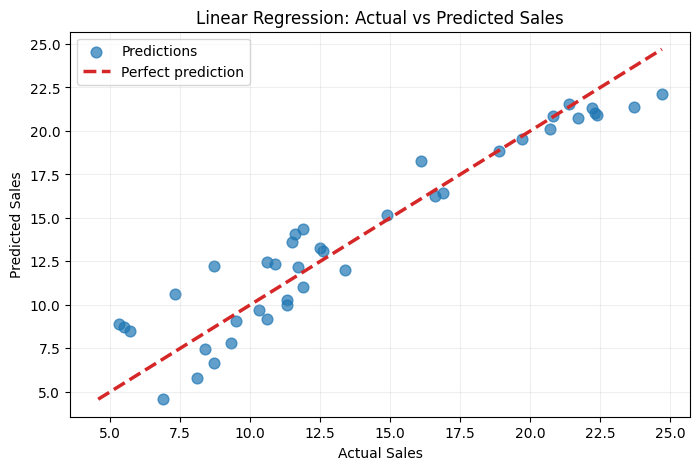

In [43]:
# ----------------------------------------------------------
# ACTUAL VS PREDICTED SALES
# ----------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred,
    color=COLORS["data"],
    alpha=0.70,
    s=60,
    label="Predictions"
)


# Ideal prediction line
minimum = min(
    y_test.min(),
    y_pred.min()
)

maximum = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color=COLORS["problem"],
    linestyle="--",
    linewidth=2.5,
    label="Perfect prediction"
)


plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title(
    "Linear Regression: Actual vs Predicted Sales"
)

plt.legend()
plt.grid(alpha=0.20)

plt.show()